# Data Exploration

**Correlation Matrix and Distribution of Selected Variables**

Author: Pete King

I want to get a better feel for how the variables relate to each other and which ones might present important features for predicting future volatility.  We can use a heatmap to visualize a correlation matrix for our data to quickly get a sense for which ones seem to be related.  We'll include the volatility for one of the ETFs as well to see how the input variables relate to one of our labels.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
DATA_FILE = 'train_ALL_DATA.csv'
TICKER = 'SPY'

In [2]:
df = pd.read_csv(
    DATA_FOLDER + DATA_FILE,
    index_col='date',
    parse_dates=True
)

## Correlation Matrix

In [3]:
X_cols, y_cols = dp.get_X_y_cols(df)
corr = df[[TICKER + '_f-vol_target'] + X_cols].corr()

<Axes: >

<Figure size 640x480 with 0 Axes>

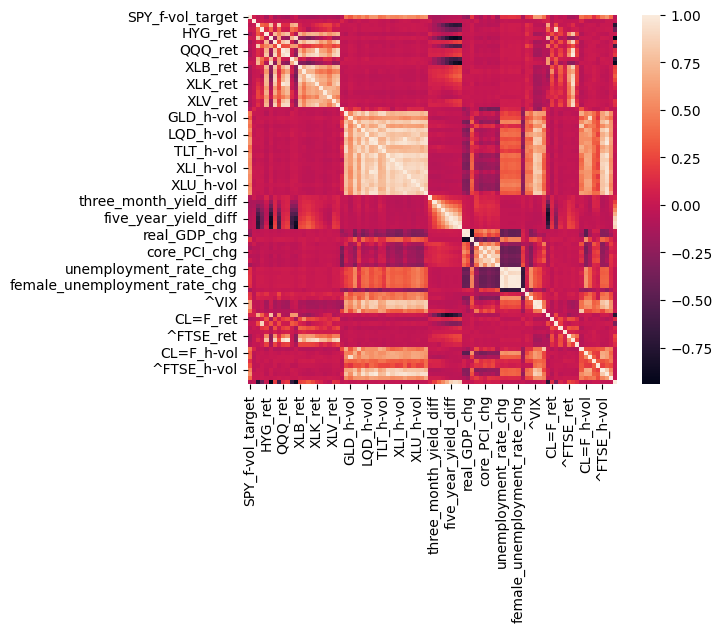

In [4]:
fig = plt.figure()
ax = plt.subplots()

sns.heatmap(corr, square=True)

The top line of pixels represents correlation with one of our target variables: future volatility for the S&P 500 ETF (SPY).  Right away we can see that while many returns exhibit correlation with each other (either positive or negative), returns are generally uncorrelated with volatililty.  We can also see that recent historical volatility for all assets shows a strong positive correlation with future volatility for the SPY.  Finally, we see that several market volatility indexes (^MOVE, ^VIX, and ^VXN) also show strong positive correlation with SPY future volatility.

The input variables showing a high degree of correlation with our target variable will likely make the best features for our models.

In [12]:
sorted(
    [(k, v) for k, v in corr['SPY_f-vol_target'].to_dict().items()],
    key=lambda x:-x[1]
)

[('SPY_f-vol_target', 1.0),
 ('^VIX', 0.6191984471202121),
 ('^VXN', 0.6134910044265045),
 ('SPY_h-vol', 0.5891677221839874),
 ('XLK_h-vol', 0.5859899300487962),
 ('XLY_h-vol', 0.581932510894751),
 ('^GSPC_h-vol', 0.5816568341887497),
 ('QQQ_h-vol', 0.5777867250764381),
 ('XLV_h-vol', 0.5513593532324343),
 ('XLB_h-vol', 0.5452275250152477),
 ('XLRE_h-vol', 0.539572949335781),
 ('XLP_h-vol', 0.535377189018016),
 ('XLI_h-vol', 0.5353438338916239),
 ('IWM_h-vol', 0.5235550969595634),
 ('XLE_h-vol', 0.5112445113021448),
 ('XLF_h-vol', 0.49840049899043903),
 ('^FTSE_h-vol', 0.4829551685855103),
 ('XLU_h-vol', 0.48170866484768887),
 ('HYG_h-vol', 0.4778136896950153),
 ('TLT_h-vol', 0.4572159211241481),
 ('BND_h-vol', 0.43414804725528966),
 ('LQD_h-vol', 0.432789090580519),
 ('^MOVE', 0.4284285529151217),
 ('TIP_h-vol', 0.4240229298810603),
 ('SHY_h-vol', 0.4236549221160218),
 ('IEF_h-vol', 0.4203509667557922),
 ('^HSI_h-vol', 0.38048780953665007),
 ('GC=F_h-vol', 0.36065926631589434),
 ('CL=